In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fraudTest.csv to fraudTest.csv


Uploading the Dataset

Importing the required Library

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset

In [ ]:
df = pd.read_csv("fraudTest.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Understanding the Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

Checking statistics:

In [ ]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


Checking missing values:

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


Converting Date Column

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

Creating Useful Features

In [ ]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

Fraud vs Non-Fraud

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,553574
1,2145


where

0 = Normal transaction

1 = Fraud transaction

Fraud by Category

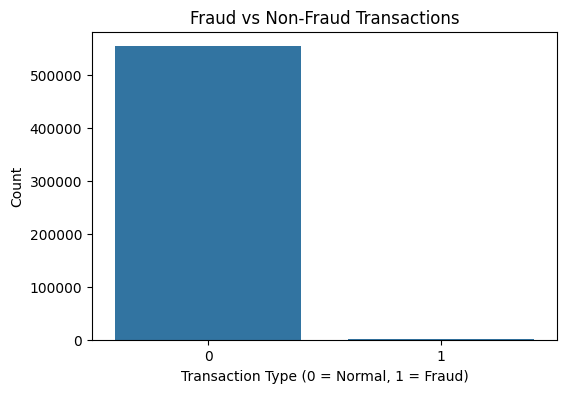

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

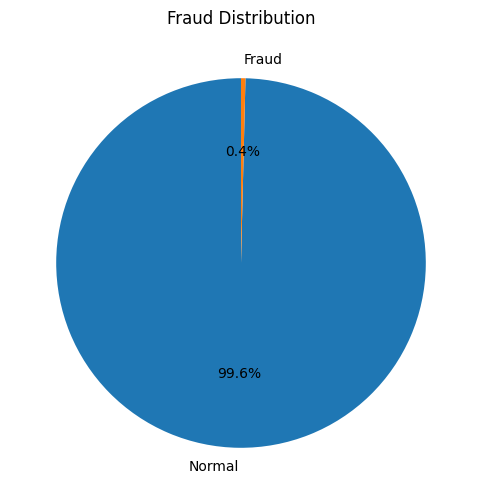

In [ ]:
fraud_counts = df['is_fraud'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fraud_counts, labels=['Normal', 'Fraud'], autopct='%1.1f%%', startangle=90)
plt.title("Fraud Distribution")

plt.show()

In [ ]:
df.groupby("category")["is_fraud"].sum().sort_values(ascending=False)

,is_fraud
category,
shopping_net,506
grocery_pos,485
misc_net,267
shopping_pos,213
gas_transport,154
misc_pos,72
personal_care,70
home,67
kids_pets,65


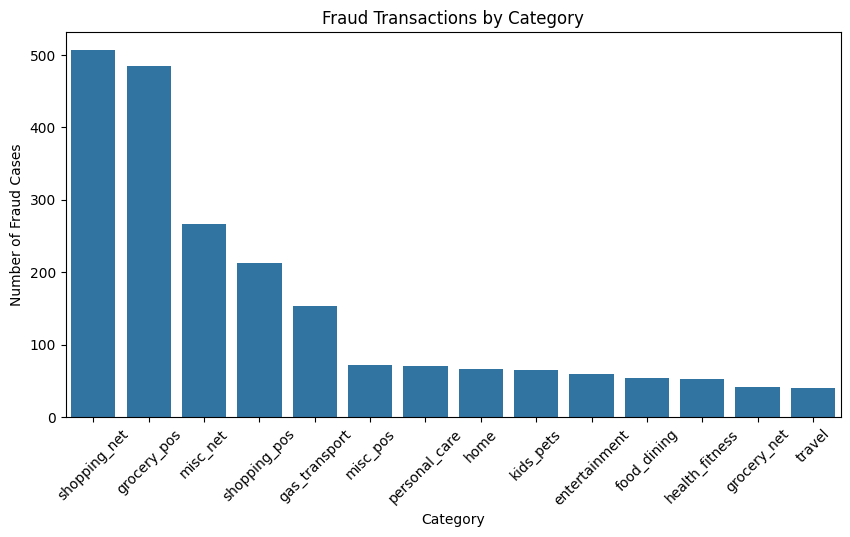

In [ ]:
plt.figure(figsize=(10,5))

fraud_category = df.groupby('category')['is_fraud'].sum().sort_values(ascending=False)

sns.barplot(x=fraud_category.index, y=fraud_category.values)

plt.title("Fraud Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Fraud Cases")
plt.xticks(rotation=45)

plt.show()

Fraud by Gender

In [ ]:
df.groupby("gender")["is_fraud"].sum()

,is_fraud
gender,
F,1164
M,981


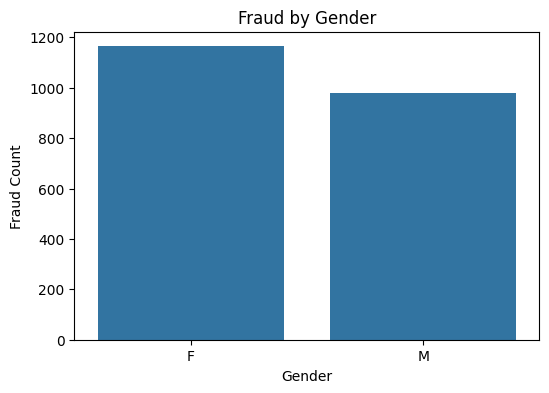

In [ ]:
plt.figure(figsize=(6,4))

fraud_gender = df.groupby('gender')['is_fraud'].sum()

sns.barplot(x=fraud_gender.index, y=fraud_gender.values)

plt.title("Fraud by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Count")

plt.show()

Fraud by State

In [ ]:
df.groupby("state")["is_fraud"].sum().sort_values(ascending=False)

,is_fraud
state,
NY,175
PA,114
TX,113
IL,76
CA,76
IN,75
VA,75
MN,73
MO,71


Transaction Amout Distribution

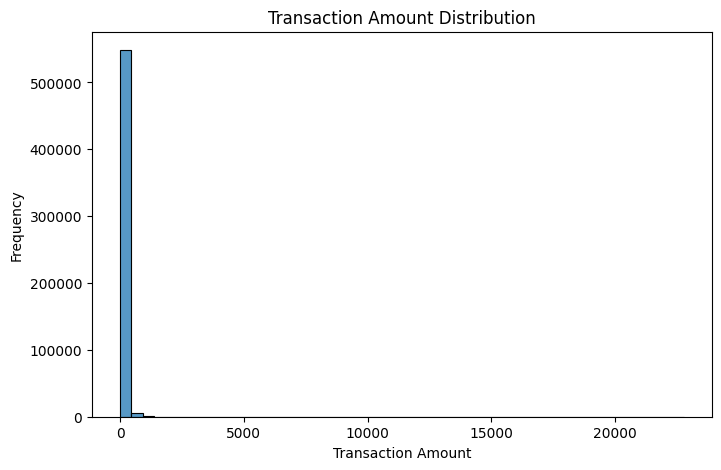

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['amt'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

Fraud vs Amount

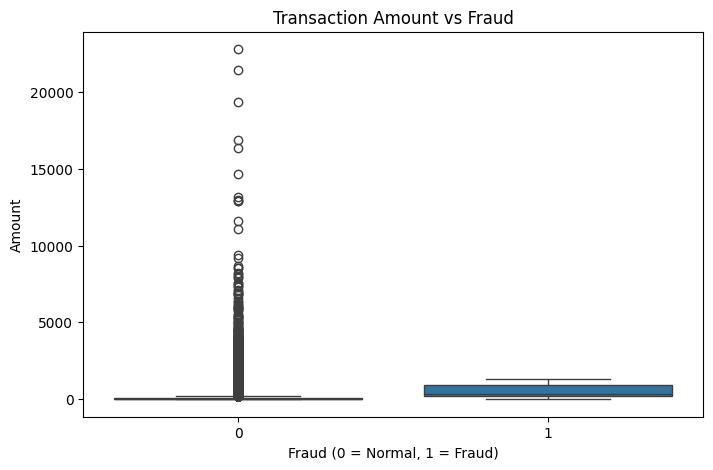

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='is_fraud', y='amt', data=df)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

In [ ]:
df.to_csv("cleaned_fraud_data.csv", index=False)

Downloading the file

In [ ]:
files.download("cleaned_fraud_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>